# Extended Data Figure 4

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import os
import pandas as pd
import seaborn as sns
from scipy import sparse
from scipy.signal import savgol_filter
from scipy.stats import linregress
from scipy.sparse.linalg import spsolve

# Remove top and right axis from plots:
mpl.rcParams['pdf.fonttype'] = 42


EGlu = -70.748 mV, SEM = 4.975 mV, n = 12 cells
EACh = -6.464 mV, SEM = 6.414 mV, n = 6 cells
EGABA = -67.92 mV, SEM = 6.433 mV, n = 5 cells
EGluClα RNAi = -38.087 mV, SEM = 13.015 mV, n = 6 cells


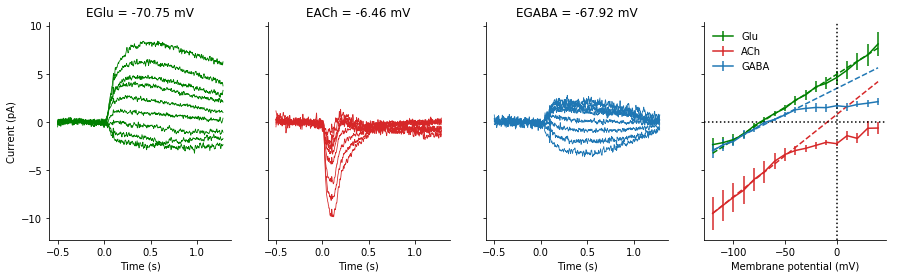

In [2]:
# Extended Data Figure 4b: 
# Load data:
os.chdir('../Fig. 2')
data = pd.read_csv("fig2fedfig4b_currents.csv", index_col=None)
peak_data = pd.read_csv("fig2fedfig4b_iv.csv", index_col=None)
os.chdir('../ED Fig. 4')

# Calculate reversal potentials:
Erev = pd.DataFrame()
for t in peak_data.Transmitter.unique():
    for c in peak_data.query("Transmitter == @t").cell.unique():
        df = pd.DataFrame()
        df['Transmitter'] = [t]
        df['cell'] = [c]
        V = peak_data.query("Transmitter == @t and cell == @c and -100 <= voltage <= -40").voltage.values
        I = peak_data.query("Transmitter == @t and cell == @c and -100 <= voltage <= -40").current.values
        lr = linregress(V,I)
        df['intercept'] = [lr.intercept]
        df['slope'] = [lr.slope]
        erev = -lr.intercept/lr.slope
        df['Erev'] = [erev]
        Erev = Erev.append(df)
        
for t in Erev.Transmitter.unique():
    print('E{}'.format(t),
          '= {} mV,'.format(np.around(Erev.query("Transmitter == @t").Erev.mean(), decimals = 3)),
          'SEM = {} mV,'.format(np.around(Erev.query("Transmitter == @t").Erev.sem(), decimals = 3)),
          'n = {} cells'.format(len(Erev.query("Transmitter == @t").cell.unique())))
    
lin_fit_params = Erev.groupby(['Transmitter']).mean()

# Plot:
cd = data.groupby(['Transmitter', 'voltage', 'new_time']).mean().reset_index().query("Transmitter != 'GluClα RNAi'")
cdp = peak_data.query("Transmitter != 'GluClα RNAi'")
cdp_mean = cdp.groupby(['Transmitter', 'voltage']).mean().reset_index()
cdp_sem = cdp.groupby(['Transmitter', 'voltage']).sem().reset_index()
pdsf = 5
transmitters = ['Glu', 'ACh', 'GABA']
colours=['g', 'C3', 'C0']

fig, ax = plt.subplots(1, len(cd.Transmitter.unique())+1, figsize=(15, 4), sharey=True)
sns.despine()
for idx, t in enumerate(transmitters):
    for v in cd.voltage.unique()[::2]:
        ax[idx].plot(cd.query("Transmitter == @t and voltage == @v").new_time[::pdsf], 
                     savgol_filter(cd.query("Transmitter == @t and voltage == @v").current, 35, 2)[::pdsf], c=colours[idx], alpha=1.0, linewidth=0.8)
    ax[idx].set_xlabel('Time (s)')
    ax[idx].set_title('E{0} = {1} mV'.format(transmitters[idx], np.around(lin_fit_params.query("Transmitter == @t").Erev.values[0], decimals=2)))
    ax[-1].errorbar(cdp_mean.query("Transmitter == @t").voltage, cdp_mean.query("Transmitter == @t").current,
            yerr=cdp_sem.query("Transmitter == @t").current, c=colours[idx], label=transmitters[idx])

for idx, t in enumerate(transmitters):
    i = lin_fit_params.query("Transmitter == @t").intercept.values
    s = lin_fit_params.query("Transmitter == @t").slope.values
    x = np.linspace(-120,40,10)
    y = s*x+i
    ax[-1].plot(x, y, color = colours[idx], linestyle = '--')
    
ax[-1].axhline(y = 0, color='k',linestyle='dotted')
ax[-1].axvline(x = 0, color='k',linestyle='dotted')
ax[0].set_ylabel('Current (pA)')
ax[-1].set_xlabel('Membrane potential (mV)')
plt.legend(frameon=False);
#plt.savefig('edfig4b.pdf');

Glutamate: Erev = -70.0 mV
Clamp potential = -120.0 mV
Clamp potential = -100.0 mV
Clamp potential = -80.0 mV
Clamp potential = -60.0 mV
Clamp potential = -40.0 mV
Clamp potential = -20.0 mV
Clamp potential = 0.0 mV
Clamp potential = 20.0 mV
Clamp potential = 40.0 mV
Erev dendrite = -70.0 mV
Erev soma = -70.0 mV

Acetylcholine: Erev = -21.0 mV
Clamp potential = -120.0 mV
Clamp potential = -100.0 mV
Clamp potential = -80.0 mV
Clamp potential = -60.0 mV
Clamp potential = -40.0 mV
Clamp potential = -20.0 mV
Clamp potential = 0.0 mV
Clamp potential = 20.0 mV
Clamp potential = 40.0 mV
Erev dendrite = -21.0 mV
Erev soma = -2.492 mV

GABA: Erev = -68.0 mV
Clamp potential = -120.0 mV
Clamp potential = -100.0 mV
Clamp potential = -80.0 mV
Clamp potential = -60.0 mV
Clamp potential = -40.0 mV
Clamp potential = -20.0 mV
Clamp potential = 0.0 mV
Clamp potential = 20.0 mV
Clamp potential = 40.0 mV
Erev dendrite = -68.0 mV
Erev soma = -67.244 mV



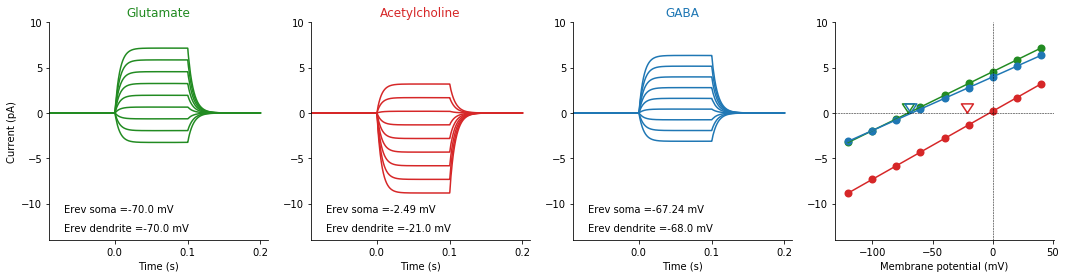

In [3]:
# Extended Data Figure 4d:
# Calculate conductance matrix:
def calc_Conductance_M(mycell, Rm=28000.0, Ra=150.0, Cm=1.0, deltat=0.001):

    # Define matrix M:
    interim = mycell.shape
    nofcomps = interim[0]
            
    M = np.zeros((nofcomps,nofcomps))

    # Compute diameter (swc file holds radii in position 5):
    compdiam = mycell[:,5]*2.0    # diameter in µm
    complength = np.zeros(nofcomps)
    
    # Complength defined backwards:
    for i in range(1,nofcomps,1):
            
            aind = int(mycell[i,0]-1)
            bind = int(mycell[i,6]-1)
            axyz = mycell[aind,2:5]
            bxyz = mycell[bind,2:5]
            
            complength[i] = np.sqrt(np.sum((axyz-bxyz)**2)) # in µm
            
            meandiam = (compdiam[aind]+compdiam[bind])*0.5
            area = meandiam**2.0/4.0*np.pi
            M[bind,aind] = -area/complength[aind]/Ra*10**(-4)
            M[aind,bind] = M[bind,aind]
            
    complength[0] = complength[1]
    
    gleak = (compdiam*np.pi*complength)/(Rm*10**8)
    memcap = (compdiam*np.pi*complength)*Cm*(10**-6)/(10**8)
    
    for i in range(nofcomps):
        M[i,i] = gleak[i]-np.sum(M[i])
    
    M = sparse.csr_matrix(M)
        
    return M, memcap, gleak

# Define model specifics:
maxtime = 3500
deltat = 0.0001  #  timestep in seconds (i.e. 0.1 msec)     
myt = np.arange(maxtime)*deltat

# Load EM-reconstructed T4 cell morphology (Shinomiya et al., eLife 2019):
mycell = np.loadtxt('edfig4c_T4a_85.swc')

# Compartment numbers:
soma = 1735
dend = 1107
axterm = 2000

mycell[:,2:6] = 0.01*mycell[:,2:6]   
interim = mycell.shape
nofcomps = interim[0] 

# Define passive membrane properties:
Eleak = -0.070 # leak reversal potential (V) (i.e. -70 mV)
Rm = 28000.0 # membrane resistance (kΩcm**2)
Ra = 150.0 # axial resistivity (Ωcm)
Cm = 1.0 # membrane capacitance (μF/cm**2)

# Load synapse locations of respective presynaptic partners:
Mi1synlocs = np.load('edfig4c_Mi1synlocs.npy',allow_pickle=True)
Mi4synlocs = np.load('edfig4c_Mi4synlocs.npy',allow_pickle=True)
Mi9synlocs = np.load('edfig4c_Mi9synlocs.npy',allow_pickle=True)
Tm3synlocs = np.load('edfig4c_Tm3synlocs.npy',allow_pickle=True)
CT1synlocs = np.load('edfig4c_CT1synlocs.npy',allow_pickle=True)
C3synlocs = np.load('edfig4c_C3synlocs.npy',allow_pickle=True)

# Voltage clamp simulations:
def VClamp(SynComps, ESyn=-0.01, Amount=100, injcompswitch=1, ClampPot=-0.05):
    
    if injcompswitch == 1: 
        injcomp = soma
        
    if injcompswitch == 2:
        injcomp = dend
    
    # Calculate matrix:
    M, memcap, gleak = calc_Conductance_M(mycell, Rm=Rm, Ra=Ra, Cm=Cm, deltat=deltat)
    
    # Define membrane potential and injected current:
    Vm = np.zeros((nofcomps,maxtime)) + Eleak
    currinj = np.zeros(nofcomps) 
    VmClamp = np.zeros(maxtime)+Eleak
    curramp = np.zeros(maxtime)
    
    tstart = 0 #100
    tstop = 3500 #2900
    
    currinj[injcomp] = 1.0
    VmClamp[tstart:tstop] = ClampPot
    
    # Define synaptic compartments and input:
    SynInput=np.zeros((nofcomps,maxtime))
    SynInput[SynComps,1500:2500] = Amount*(10**-12)
    
    #### End of initialization ####
    
    gain = 2000.0
    
    M_actual = 1.0*M
    
    for t in range(1, maxtime):
        # Proportional integral control loop:
        curramp[t] = gain*(VmClamp[t]-Vm[injcomp,t-1])*10**(-12) + curramp[t-1]
        
        M_actual.setdiag(M.diagonal()+SynInput[:,t]+memcap/deltat)
        rightsideofeq = Vm[:,t-1]*memcap/deltat+currinj[:]*curramp[t]+Eleak*gleak+ESyn*SynInput[:,t]
        
        Vm[:,t] = spsolve(M_actual,rightsideofeq)
    
    #Rin = (Vm[injcomp,900]-Vm[injcomp,0])/curramp[900]/(10**9) # GOhm
    
    Vm[:,:] = 1000.0*Vm # mV
    
    #print('Rin = ', int(Rin*100)*0.01, 'GΩ')
    
    return curramp
    
# Calculate reversal potentials:    
def calc_zero_crossing(p1,p2):
    
    x1 = p1[0]
    x2 = p2[0]
    y1 = p1[1]
    y2 = p2[1]
    
    m = (y1-y2)/(x1-x2)
    t = y1-m*x1
    
    zero_crossing = -t/m
    
    return zero_crossing
    

def myscript(choice):
    
    if choice == 0:
        synlocs = Mi9synlocs[1]
        ESyn = -0.070
        transmitter = 10
        print('Glutamate: Erev =', np.around(ESyn*1000, decimals=3), 'mV')
    if choice == 1:
        synlocs = Mi1synlocs[0]
        ESyn = -0.021
        transmitter = 4
        print('Acetylcholine: Erev =', np.around(ESyn*1000, decimals=3), 'mV')
    if choice == 2:
        synlocs = Mi4synlocs[4]+Mi4synlocs[5]
        ESyn = -0.068
        transmitter = 10
        print('GABA: Erev =', np.around(ESyn*1000, decimals=3), 'mV')
    
    current = np.zeros((9,maxtime))
    
    for i in range(0,9):
        CPot = -0.120+i*0.01*2
        print('Clamp potential =', np.around(CPot*1000., decimals=1), 'mV')
        current[i] = VClamp(synlocs, ESyn=ESyn, Amount=transmitter, ClampPot=CPot)
        
    current = current*10**12  
    mydata = current[:,2000] - current[:,1300]
    p1 = [-120.0,mydata[0]]
    p2 = [+40.0,mydata[8]]
    ErevSoma = calc_zero_crossing(p1,p2)
    
    print('Erev dendrite =', np.around(ESyn*1000, decimals=3), 'mV')
    print('Erev soma =', np.around(ErevSoma, decimals=3), 'mV')
    print()
    
    return current
    
    
def calc_all():
    
    current_Glu = myscript(0)
    current_ACh = myscript(1)
    current_GABA = myscript(2)
    
    return current_Glu, current_ACh, current_GABA
    
    
def plot(a,b,c):
    
    myt = np.arange(maxtime)*0.0001
    vclamp = np.arange(9)*20.-120.
    
    current = np.zeros((3,9,maxtime))
    
    mycolour = ['forestgreen', 'C3', 'C0']
    mytitle = ['Glutamate', 'Acetylcholine', 'GABA']
    
    current[0] = a
    current[1] = b
    current[2] = c
    
    ymin = -14
    ymax = +10
    
    Esyn = [-0.070, -0.021, -0.068]
    
    fig = plt.figure(figsize=(18,4))
    
    for j in range(3):
        ax1 = fig.add_subplot(1, 4, j+1)
        for i in range(9):
            ax1.plot(myt[100:],current[j,i,100:]-current[j,i,1300],color=mycolour[j])
        
        ax1.set_ybound(ymin,ymax)
        ax1.set_xlim(0.06,0.36)
        ax1.xaxis.set_ticks([0.15, 0.25, 0.35])
        ax1.xaxis.set_ticklabels([0.0, 0.1, 0.2])
        ax1.set_title(mytitle[j], color=mycolour[j])
            
        if j == 0: 
            ax1.set_ylabel('Current (pA)')
        ax1.set_xlabel('Time (s)')
        
        mydata = current[j,:,2000] - current[j,:,1300]
        
        p1 = [-120.0, mydata[0]]
        p2 = [+40.0, mydata[8]]
        
        zero = calc_zero_crossing(p1,p2)
        
        xpos = 0.08
        
        ax1.text(xpos,-11.0,'Erev soma ='+str(np.around(int(zero*100)*0.01, decimals=3))+' mV')
        ax1.text(xpos,-13.0,'Erev dendrite ='+str(np.around(int(Esyn[j]*100000)*0.01, decimals=3))+' mV')
        
    ax2 = fig.add_subplot(1,4,4)
    
    for j in range(3):
        
        mydata = current[j,:,2000]-current[j,:,1300]
        
        ax2.scatter(vclamp, mydata, linewidth=2, color=mycolour[j])
        ax2.plot(vclamp, mydata, color=mycolour[j])
        
        xpos, ypos = [Esyn[j]*1000, Esyn[j]*1000-5,Esyn[j]*1000+5, Esyn[j]*1000],[0,1,1,0]
        ax2.plot(xpos,ypos,color=mycolour[j])
        
    ax2.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax2.set_xlabel('Membrane potential (mV)')
    ax2.set_ybound(ymin, ymax)
    #ax2.set_xbound(-130, +50)
    sns.despine()
    #plt.savefig('edfig4d.pdf')
    plt.show();
    
Glu, ACh, GABA = calc_all()
plot(Glu, ACh, GABA)

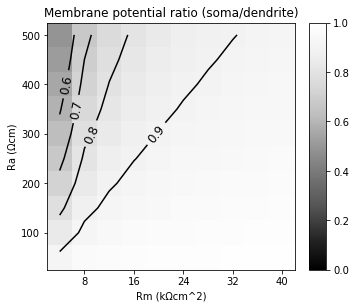

In [4]:
# Extended Data Figure 4f:
pal = sns.diverging_palette(250, 13, s=100, l=35, sep=2, center='light', as_cmap=True)
maps = np.load('edfig4_rins_ratios.npy')

data = maps[1,:,:]
levels = [0.6, 0.7, 0.8, 0.9]

fig, ax = plt.subplots(1,1,figsize=(5,5))
heat = ax.imshow(data, vmin=0, vmax=1, origin="lower", cmap="Greys_r")
contours = ax.contour(data, levels=levels, colors='k')
ax.clabel(contours, colors = 'k', fmt = '%2.1f', fontsize=12)
plt.title('Membrane potential ratio (soma/dendrite)')
ax.set_xlabel('Rm (kΩcm^2)')
ax.set_ylabel('Ra (Ωcm)')
ax.set_xticks(np.arange(1,10,2))
ax.set_xticklabels(np.arange(8,44,8))
ax.set_yticks(np.arange(1,10,2))
ax.set_yticklabels(np.arange(100, 550, 100))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='7%', pad=0.2)
fig.colorbar(heat, cax=cax, orientation='vertical');
#plt.savefig('edfig4f.pdf')

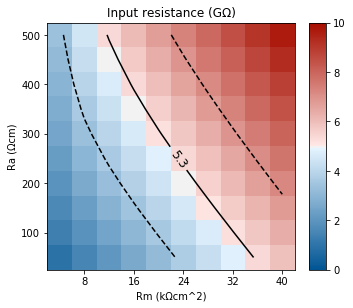

In [5]:
# Extended Data Figure 4g:
# Measured data (from Fig. 2h): 
mean = [5.283]
sd = [3.546, 7.02]

# Modelled data:
data = maps[0,:,:]

fig, ax = plt.subplots(1,1,figsize=(5,5))

heat = ax.imshow(data,vmin=0, vmax=10,origin='lower', cmap=pal)
#heat = ax.pcolormesh(data, cmap=pal)
#heat = sns.heatmap(data cmap=pal)
mean = ax.contour(data, levels=mean, colors='k')
sd = ax.contour(data, levels=sd, colors='k', linestyles='--')
ax.clabel(mean, colors = 'k', fmt = '%2.1f', fontsize=12)
plt.title('Input resistance (GΩ)')
ax.set_xlabel('Rm (kΩcm^2)')
ax.set_ylabel('Ra (Ωcm)')
ax.set_xticks(np.arange(1,10,2))
ax.set_xticklabels(np.arange(8,44,8))
ax.set_yticks(np.arange(1,10,2))
ax.set_yticklabels(np.arange(100, 550, 100))
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='7%', pad=0.2)
fig.colorbar(heat, cax=cax, orientation='vertical');
#plt.savefig('edfig4g.pdf')